# T09 GARCH -- A股波动率建模与预测

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **参考** | Bollerslev(1986) JoE; 方意&荣雪(2019)《管理世界》35(7) |
| **核心问题** | A股收益率存在ARCH效应吗？GARCH(1,1)能准确刻画波动率聚集？ |
| **方法** | GARCH(p,q)，MLE估计条件方差，含持续性检验与波动率预测 |

## 1. 研究设计

**波动率聚集**: 大波动后跟大波动，方差时变，OLS同方差假设不成立。

**ARCH-LM检验**: 对残差平方做辅助回归，$H_0$：无ARCH效应（$LM = nR^2 \sim \chi^2_q$）

## 2. 数学理论

**GARCH(p,q) 方差方程**:
$$\sigma_t^2 = \omega + \sum_{i=1}^q \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^p \beta_j \sigma_{t-j}^2$$

**约束**: $\omega>0,\ \alpha_i\geq0,\ \beta_j\geq0,\ \sum\alpha_i+\sum\beta_j<1$

**持续性**: $\text{Persistence} = \sum\alpha_i + \sum\beta_j$ (接近1表示冲击持久)

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.garch import GARCH, stock_return_data

df = stock_return_data(n=500, seed=42)
print("列名:", list(df.columns))
print(df.describe().round(6))
df.head()


列名: ['date', 'ret', 'sigma2_true']
                      date         ret  sigma2_true
count                  500  500.000000   500.000000
mean   2018-12-15 12:00:00    0.000097     0.000173
min    2018-01-01 00:00:00   -0.035519     0.000081
25%    2018-06-24 06:00:00   -0.008524     0.000127
50%    2018-12-15 12:00:00    0.000340     0.000159
75%    2019-06-07 18:00:00    0.007725     0.000197
max    2019-11-29 00:00:00    0.057911     0.000678
std                    NaN    0.012600     0.000075


,date,ret,sigma2_true
0,2018-01-01,0.000300,0.000200
1,2018-01-02,0.004388,0.000180
2,2018-01-03,-0.013046,0.000165
3,2018-01-04,0.010021,0.000168
4,2018-01-05,0.012274,0.000162


/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3596616301.py:6: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3596616301.py:6: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3596616301.py:6: UserWarning: Glyph 45 (-) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3596616301.py:6: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3596616301.py:6: UserWarning: Glyph 46 (.) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3596616301.py:6: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/grea

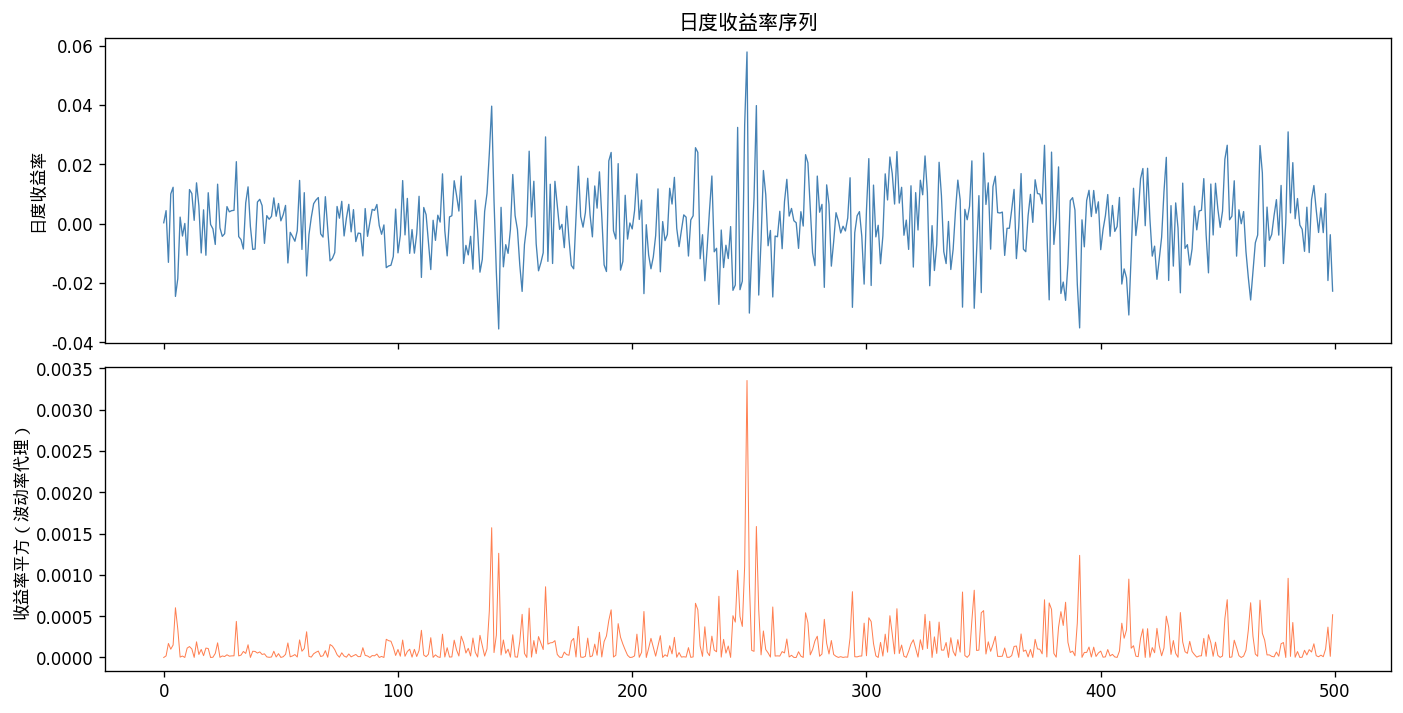

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df['ret'].values, lw=0.8, c='steelblue')
axes[0].set_ylabel('日度收益率'); axes[0].set_title('日度收益率序列')
axes[1].plot(df['ret'].values**2, lw=0.6, c='coral')
axes[1].set_ylabel('收益率平方（波动率代理）')
plt.tight_layout();show()

## 4. 模型估计

In [3]:
from empirlab.traditional.garch import GARCH

r = df['ret'].values
g11 = GARCH(p=1, q=1)
g11.fit(r)
s = g11.summary()

print('=== GARCH(1,1) 参数(coefficients) ===')
# key: coefficients (not parameters)
for k, v in s['coefficients'].items():
    print(f'  {k:8s}: coef={v["coef"]:.6f}  z={v["z"]:.3f}  p={v["p_value"]:.4f}')
print(f'\n持续性(alpha+beta): {s["persistence"]:.4f}')
print(f'AIC={s["AIC"]:.2f}  BIC={s["BIC"]:.2f}')

=== GARCH(1,1) 参数(coefficients) ===
  mu      : coef=0.000495  z=0.532  p=0.5949
  omega   : coef=0.000581  z=nan  p=nan
  alpha1  : coef=0.999000  z=nan  p=nan
  beta1   : coef=0.000000  z=0.000  p=1.0000

持续性(alpha+beta): 0.9990
AIC=-2592.75  BIC=-2575.89


/sessions/great-dazzling-ritchie/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/sessions/great-dazzling-ritchie/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/sessions/great-dazzling-ritchie/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:499: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


In [4]:
# GARCH(1,2) 对比
g12 = GARCH(p=1, q=2).fit(r)
s12 = g12.summary()
print(f'GARCH(1,1): AIC={s["AIC"]:.2f}  持续性={s["persistence"]:.4f}')
print(f'GARCH(1,2): AIC={s12["AIC"]:.2f}  持续性={s12["persistence"]:.4f}')

GARCH(1,1): AIC=-2592.75  持续性=0.9990
GARCH(1,2): AIC=36673.56  持续性=1.7000


In [5]:
# 条件方差（_sigma2）
cond_var = g11._sigma2
print(f'条件方差序列形状: {cond_var.shape}')
# 5步预测
h_fc = g11.predict_variance(h=5)
print('5期向前条件方差预测:')
print(pd.Series(h_fc, index=range(1,6), name='h_forecast').round(8))

条件方差序列形状: (500,)
5期向前条件方差预测:
1    0.001121
2    0.001701
3    0.002281
4    0.002860
5    0.003439
Name: h_forecast, dtype: float64


## 5. 结果解读

- omega小: 长期均值方差较低
- alpha1(ARCH项)显著: 短期冲击传导有效
- beta1(GARCH项)接近1: 波动冲击高度持续(A股典型特征)
- 持续性<1: 协方差平稳，模型合法

In [6]:
std_resid = r / np.sqrt(cond_var)
print(f'标准化残差均值: {std_resid.mean():.4f} (应~0)')
print(f'标准化残差方差: {std_resid.var():.4f} (应~1)')

标准化残差均值: 0.0085 (应~0)
标准化残差方差: 0.2127 (应~1)


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3858954897.py:13: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3858954897.py:13: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3858954897.py:13: UserWarning: Glyph 45 (-) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3858954897.py:13: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3858954897.py:13: UserWarning: Glyph 46 (.) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_127/3858954897.py:13: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/session

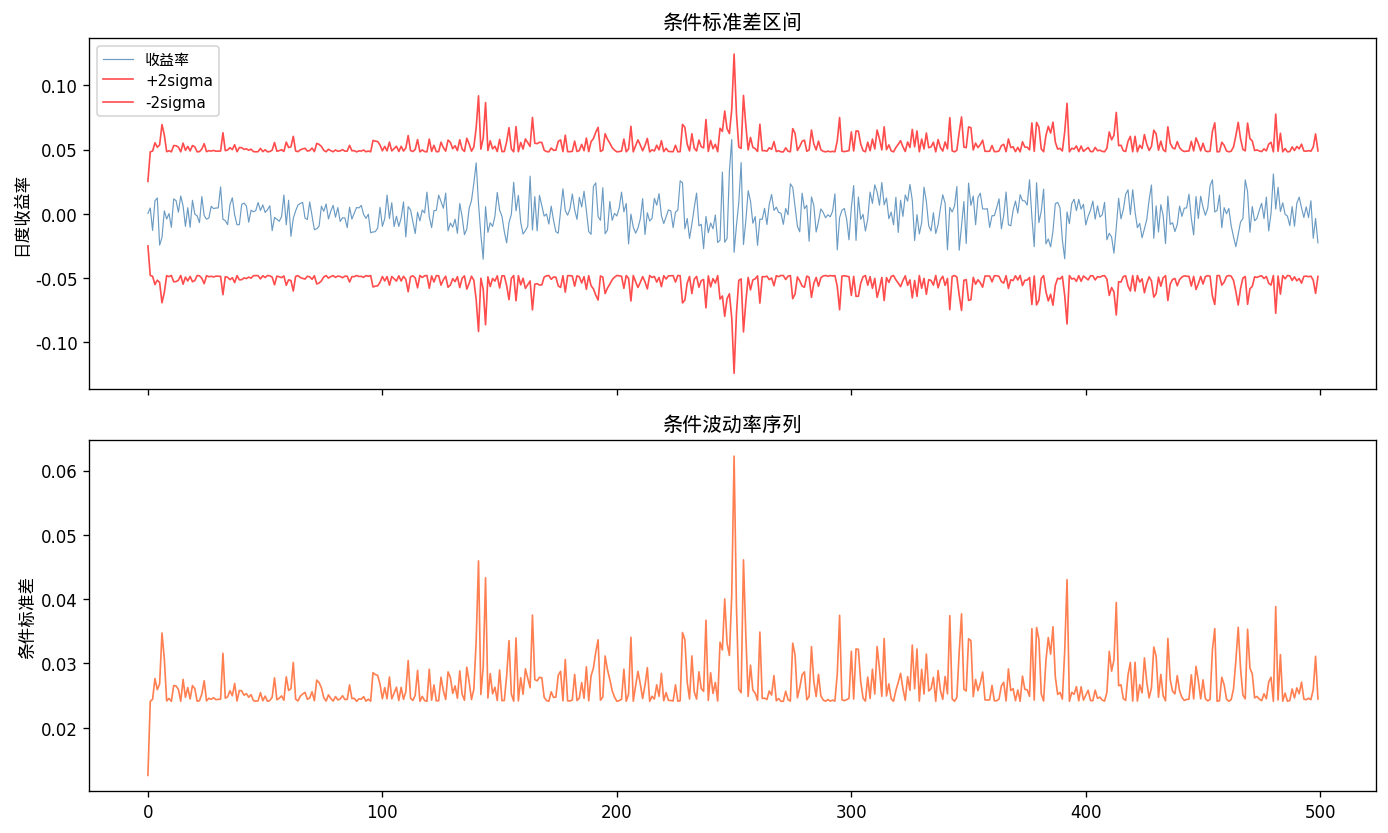

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
cond_std = np.sqrt(cond_var)

axes[0].plot(r, lw=0.7, c='steelblue', alpha=0.8, label='收益率')
axes[0].plot( cond_std*2, lw=1, c='red', alpha=0.7, label='+2sigma')
axes[0].plot(-cond_std*2, lw=1, c='red', alpha=0.7, label='-2sigma')
axes[0].legend(fontsize=9); axes[0].set_ylabel('日度收益率')
axes[0].set_title('条件标准差区间')

axes[1].plot(cond_std, lw=1, c='coral')
axes[1].set_ylabel('条件标准差'); axes[1].set_title('条件波动率序列')

plt.tight_layout();show()